# Processing tidal gage data

### Import statements

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
import seaborn as sns

In [3]:
gage = pd.read_csv('usgs_data_hre.txt', sep='\t', header=24)
gage = gage.drop(0)
gage['datetime'] = pd.to_datetime(gage['datetime'], format='%Y-%m-%d %H:%M')
gage['218558_00065'] = pd.to_numeric(gage['218558_00065'], errors='coerce')
gage['66254_00065'] = pd.to_numeric(gage['66254_00065'], errors='coerce')
gage.rename(columns={'218558_00065':'Ocean side', '66254_00065':'River side'}, inplace=True)

gage = gage[['datetime','Ocean side','River side']]

start_date = datetime(2022, 7, 14, 18, 0, 0, 0)
end_date = datetime(2022, 7, 15, 6, 0, 0, 0)
gage = gage[(gage['datetime'] > start_date) & (gage['datetime'] < end_date)]

gage['head'] = gage['River side'] - gage['Ocean side']
gage_scaled = pd.DataFrame({'datetime':gage['datetime'],'Ocean side':gage['Ocean side']/3.05, 'River side':gage['River side']/3.05, 'Head':gage['head']/3.05})
gage_scaled['Ocean side'] = gage_scaled['Ocean side']*0.3048 # convert to m
gage_scaled['River side'] = gage_scaled['River side']*0.3048
gage_scaled['Head'] = gage_scaled['Head']*0.3048

## Original, unscaled hydrograph

Tidal culvert becomes submerged once gage height > 1.55 m on the bay side.
Bottom of culvert is 2.7 m below the entrance height.

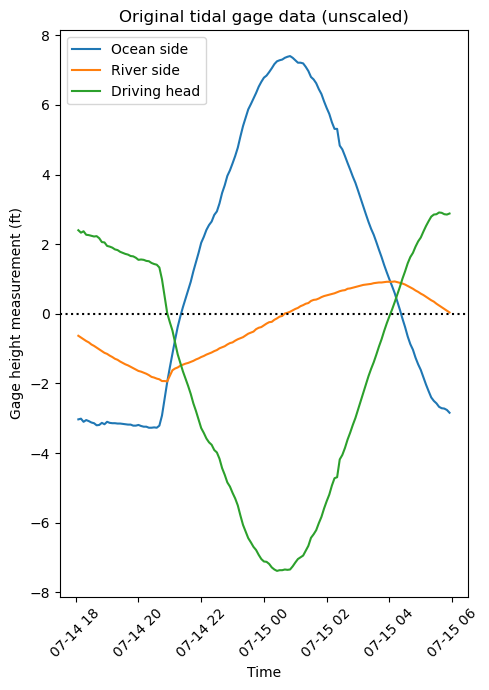

In [4]:
plt.figure(figsize=(5,7))

sns.lineplot(x='datetime', y='Ocean side', data=gage, label='Ocean side')
sns.lineplot(x='datetime', y='River side', data=gage, label='River side')
sns.lineplot(x='datetime', y='head', data=gage, label='Driving head')
plt.axhline(0, linestyle=':', color='black')

plt.title('Original tidal gage data (unscaled)')
plt.xlabel('Time')
plt.ylabel('Gage height measurement (ft)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 3.05:1 scale

### Hydrograph, scaled down to 3.05:1 lab scale

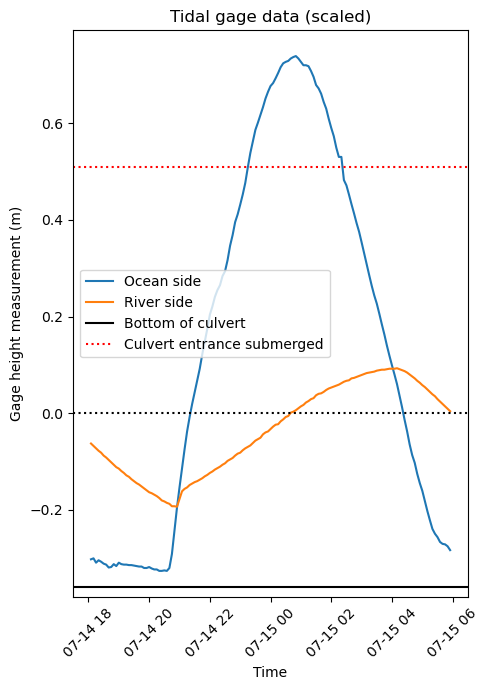

In [6]:
plt.figure(figsize=(5,7))

sns.lineplot(x='datetime', y='Ocean side', data=gage_scaled, label='Ocean side')
sns.lineplot(x='datetime', y='River side', data=gage_scaled, label='River side')
#sns.lineplot(x='datetime', y='Head', data=gage_scaled, label='Driving head')
plt.axhline(0, linestyle=':', color='black')

plt.axhline(0.51-0.87, color='black', label='Bottom of culvert')
plt.axhline(0.51, linestyle=':', color='red', label='Culvert entrance submerged')

plt.title('Tidal gage data (scaled)')
plt.xlabel('Time')
plt.ylabel('Gage height measurement (m)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 3.05:1 lab scale point finding

In [7]:
# Find indices and associated values for Ocean side + 0.36 closest to targets on either side of the peak
half_cut = datetime(2022,7,15,0)
targets = [0.4, 0.6, 0.8, 1]
results = []
for target in targets:
    # Before peak
    before = gage_scaled[gage_scaled['datetime'] < half_cut].copy()
    idx_before = (before['Ocean side'] + 0.36 - target).abs().idxmin()
    results.append({
        'Datetime': gage_scaled.loc[idx_before, 'datetime'],
        'Ocean pts': gage_scaled.loc[idx_before, 'Ocean side'] + 0.36,
        'River pts': gage_scaled.loc[idx_before, 'River side'] + 0.36,
        'Side': 'before'
    })
    # After peak
    after = gage_scaled[gage_scaled['datetime'] > half_cut].copy()
    idx_after = (after['Ocean side'] + 0.36 - target).abs().idxmin()
    results.append({
        'Datetime': gage_scaled.loc[idx_after, 'datetime'],
        'Ocean pts': gage_scaled.loc[idx_after, 'Ocean side'] + 0.36,
        'River pts': gage_scaled.loc[idx_after, 'River side'] + 0.36,
        'Side': 'after'
    })
trial_data = pd.DataFrame(results)
trial_data = trial_data.drop(1)
trial_data = trial_data.sort_values(by='Datetime')
display(trial_data)

,Datetime,Ocean pts,River pts,Side
0,2022-07-14 21:30:00,0.402972,0.217094,before
2,2022-07-14 22:10:00,0.600842,0.243077,before
4,2022-07-14 23:00:00,0.791717,0.278054,before
6,2022-07-14 23:45:00,0.993584,0.316029,before
7,2022-07-15 01:45:00,1.004577,0.403971,after
5,2022-07-15 02:40:00,0.792716,0.431953,after
3,2022-07-15 03:25:00,0.603840,0.445944,after


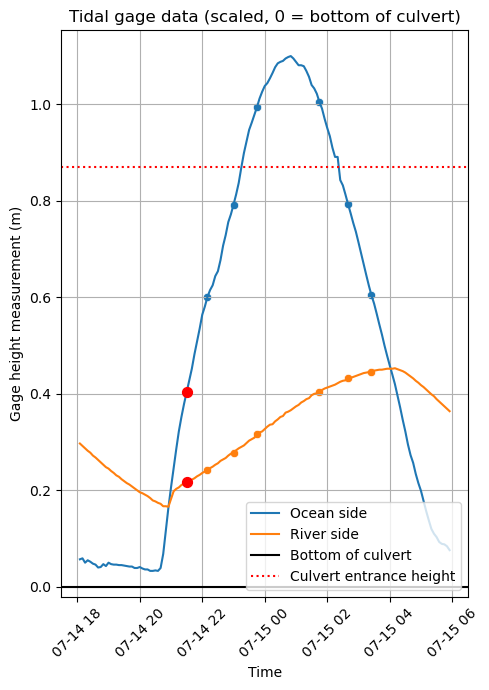

In [17]:
# create plot with culvert top and bottom, showing height relative to the bottom of the culvert.

plt.figure(figsize=(5,7))

plt.plot(gage_scaled['datetime'], gage_scaled['Ocean side']+0.36, label='Ocean side')
plt.plot(gage_scaled['datetime'], gage_scaled['River side']+0.36, label='River side')
sns.scatterplot(x='Datetime', y='Ocean pts', data=trial_data)
sns.scatterplot(x='Datetime', y='River pts', data=trial_data)

# Highlight first point by plotting it separately
first_datetime = trial_data['Datetime'].iloc[0]
first_ocean = trial_data['Ocean pts'].iloc[0]
first_river = trial_data['River pts'].iloc[0]
plt.scatter([first_datetime], [first_ocean], color='red', s=50, zorder=5)
plt.scatter([first_datetime], [first_river], color='red', s=50, zorder=5)

plt.axhline(0, color='black', label='Bottom of culvert')
plt.axhline(0.51+0.36, linestyle=':', color='red', label='Culvert entrance height')

plt.title('Tidal gage data (scaled, 0 = bottom of culvert)')
plt.xlabel('Time')
plt.ylabel('Gage height measurement (m)')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.grid(True)
plt.show()

## 6:1 lab scale

In [4]:
gage_6scale = pd.DataFrame({'datetime':gage['datetime'],'Ocean side':gage['Ocean side']/6 * 0.3048, 'River side':gage['River side']/6 * 0.3048, 'Head':gage['head']/6 * 0.3048})

### Find points

In [15]:
# Find indices and associated values for Ocean side + 0.36 closest to targets on either side of the peak
half_cut = datetime(2022,7,15,0)
targets = [0.15, 0.2, 0.3, 0.4, 0.5]
results = []
for target in targets:
    # Before peak
    before = gage_6scale[gage_6scale['datetime'] < half_cut].copy()
    idx_before = (before['Ocean side'] + 0.19 - target).abs().idxmin()
    results.append({
        'Datetime': gage_6scale.loc[idx_before, 'datetime'],
        'Ocean pts': gage_6scale.loc[idx_before, 'Ocean side'] + 0.19,
        'River pts': gage_6scale.loc[idx_before, 'River side'] + 0.19,
        'Side': 'before'
    })
    # After peak
    after = gage_6scale[gage_6scale['datetime'] > half_cut].copy()
    idx_after = (after['Ocean side'] + 0.19 - target).abs().idxmin()
    results.append({
        'Datetime': gage_6scale.loc[idx_after, 'datetime'],
        'Ocean pts': gage_6scale.loc[idx_after, 'Ocean side'] + 0.19,
        'River pts': gage_6scale.loc[idx_after, 'River side'] + 0.19,
        'Side': 'after'
    })
trial_data = pd.DataFrame(results)
trial_data = trial_data.drop(1)
trial_data = trial_data.sort_values(by='Datetime')
display(trial_data)

,Datetime,Ocean pts,River pts,Side
0,2022-07-14 21:10:00,0.151900,0.110244,before
2,2022-07-14 21:25:00,0.199652,0.115832,before
4,2022-07-14 22:05:00,0.302268,0.128532,before
6,2022-07-14 22:55:00,0.399296,0.147328,before
8,2022-07-14 23:40:00,0.503944,0.164092,before
9,2022-07-15 01:55:00,0.499880,0.215908,after
7,2022-07-15 02:45:00,0.400312,0.227084,after
5,2022-07-15 03:30:00,0.305316,0.234704,after
3,2022-07-15 04:20:00,0.196096,0.235212,after


### Hydrograph

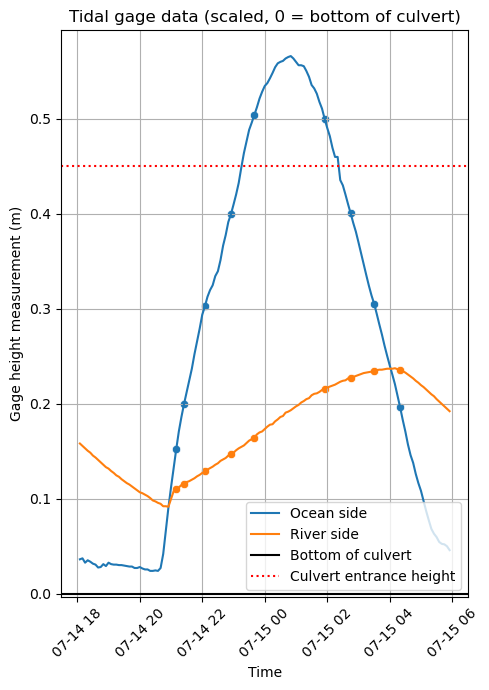

In [16]:
# create plot with culvert top and bottom, showing height relative to the bottom of the culvert.

plt.figure(figsize=(5,7))

plt.plot(gage_6scale['datetime'], gage_6scale['Ocean side']+0.19, label='Ocean side')
plt.plot(gage_6scale['datetime'], gage_6scale['River side']+0.19, label='River side')
sns.scatterplot(x='Datetime', y='Ocean pts', data=trial_data)
sns.scatterplot(x='Datetime', y='River pts', data=trial_data)

plt.axhline(0, color='black', label='Bottom of culvert')
plt.axhline(0.26+0.19, linestyle=':', color='red', label='Culvert entrance height')

plt.title('Tidal gage data (scaled, 0 = bottom of culvert)')
plt.xlabel('Time')
plt.ylabel('Gage height measurement (m)')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.grid(True)
plt.show()

Length scales to 3.8 m. Lowkey the flume is long enough for this maybe? Width scaling is messed up now but that should only affect head loss, which Todd says is minor compared to the losses in the hydraulic jump.